In [46]:
# Import libraries
import os
SEED = 42

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
!pip install torchview
from torchview import draw_graph

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import requests
from io import BytesIO

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

import cv2
import pandas as pd
from glob import glob
from tqdm import tqdm

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
PyTorch version: 2.6.0+cu124
Device: cpu


THE CODE DOES NOT ELIMINATE SHREK. TOO MANY FALSE NEGATIVES AND FALSE POSITIVES.
first I tried to remove all images with more than 30% of green, it was too much, then the upper bound was 25% and it does not detect Shrek. One kind of pictures is more green, another one is more yellow.
By the end i switched to detecting the images without magenta/ pink/ red since Shrek does not have it, but did not run the code.

while I was waiting, I manually found most of the Shrek.

In [47]:
SHREK_INDICES = {
    104, 112, 130, 147, 173, 189, 193, 203, 213, 218, 228, 237, 249, 250, 
    264, 269, 271, 290, 291, 308, 322, 328, 336, 342, 348, 357, 365, 368, 
    370, 379, 386, 391, 394, 404, 406, 413, 418, 422, 426, 430, 438, 446, 
    447, 454, 456, 469, 478, 481, 487, 492, 495, 505, 509, 514, 520, 527, 
    529, 536, 555, 574, 586, 589, 594, 606, 608, 629, 631, 648, 653, 655, 
    665, 673, 681, 703, 731, 733, 735, 748, 753, 758, 767, 771, 800, 813, 
    819, 825, 826, 832, 846, 868, 903, 919, 930, 936, 937, 958, 960, 1035, 
    1037, 1046, 1062, 1114, 1124, 1125, 1133, 1146, 1150, 1156, 1177, 1184, 
    1186, 1192, 1206, 1212, 1217, 1220, 1229, 1236, 1241, 1245, 1258, 1261, 
    1263, 1274, 1277, 1280, 1281, 1298, 1317, 1335, 1340, 1381, 1385, 1389
}

In [48]:
class Config:
    SEED = 42
    DATA_ROOT = "../input/datasetch2/"

    # The directory where the extracted files will go
    EXTRACT_DIR = DATA_ROOT
    
    PERMANENT_CLEAN_DIR = './clean_processed_data' 
    CLEAN_CSV_PATH = './clean_processed_data.csv'
    TRAIN_LABELS_CSV = os.path.join(EXTRACT_DIR, 'train_labels.csv') 
     
    
    # HSV Ranges for "Green/Yellow" artifacts (Shrek/Goo)
    # H&E is Pink/Purple. This range targets contamination.
    LOWER_GREEN = np.array([35, 60, 60]) # H=15 (more yellow), S=10 (less saturated/more gray), V=10 (darker)
    UPPER_GREEN = np.array([85, 255, 255]) # H=110 (more cyan-green)
    
    # NEW: Explicit label mapping for molecular subtypes
    LABEL_MAP = {
        'Luminal A': 0,
        'Luminal B': 1,
        'HER2': 2,
        'Triple': 3
    }


def seed_everything(seed):
    """Sets deterministic behavior across libraries."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

# REMOVE SHREK&GOO

In [49]:
def tissue_mask_lab(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L, A, B = lab[:,:,0], lab[:,:,1], lab[:,:,2]

    mask = (
        (A > 135) & (A < 185) &     # reddish channel
        (B > 120) & (B < 180) &     # yellowish but moderate
        (L > 30)  & (L < 235)       # exclude dark artifacts & background
    )

    return mask

In [50]:
def analyze_image_content(image_path):
    """
    Analyzes image content based on color contamination (Green/Yellow) 
    relative to the actual tissue area.
    Returns 0 (Valid), 1 (Repairable/Goo), 2 (Trash/Shrek).
    """
    try:
        img = cv2.imread(image_path)
        if img is None: return 2
        
        # 1. Identify "Content" (Non-white pixels - the actual tissue)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Check for tissue presence (darker than white background)
        tissue_mask = gray < 235 
        tissue_count = np.count_nonzero(tissue_mask)
        
        if tissue_count < 100:
            print(f"trash little image {os.path.basename(image_path)}")
            return 2 # Treat as empty slide if tissue area is too small

        green_mask = cv2.inRange(hsv, Config.LOWER_GREEN, Config.UPPER_GREEN)


        yellowish_lower = np.array([20, 40, 40])
        yellowish_upper = np.array([40, 255, 255])
        yellow_mask = cv2.inRange(hsv, yellowish_lower, yellowish_upper)

        # Combined "Shrek contamination"
        shrek_mask = cv2.bitwise_or(green_mask, yellow_mask)
        shrek_count = np.count_nonzero(shrek_mask)

        # ---------------------------
        # 3. Relative contamination ratio
        # ---------------------------
        green_ratio = shrek_count / tissue_count
        # # 2. Identify "Green/Shrek" pixels using HSV ranges
        # green_mask = cv2.inRange(hsv, Config.LOWER_GREEN, Config.UPPER_GREEN)
        # green_count = np.count_nonzero(green_mask)
        
        # # 3. Calculate Relative Density
        # green_ratio = green_count / tissue_count
        
        # THRESHOLDS
        # Note: Since the hard filter is removed below, the 0.30 threshold 
        # is mainly for logging/flagging as 'highly contaminated' (status 2) 
        # and ensuring it is flagged for repair.
        if green_ratio > 0.15: 
            return 2 # Highly contaminated (Shrek)
        elif green_ratio > 0.01:
            return 1 # Moderately contaminated (Goo)
        else:
            return 0 # Clean
            
    except Exception as e:
        print(f"Error processing {os.path.basename(image_path)}: {e}")
        return 2

In [51]:
def get_clean_dataframe(data_root):
    """
    Scans the data directory, loads external labels, merges them, 
    analyzes image content, filters out Shrek, and returns a clean DataFrame.
    """
    # 1. Load Labels
    if not os.path.exists(Config.TRAIN_LABELS_CSV):
        print(f"Error: Label CSV not found at {Config.TRAIN_LABELS_CSV}. Cannot proceed.")
        return pd.DataFrame()
        
    labels_df = pd.read_csv(Config.TRAIN_LABELS_CSV)

    # We must parse the integer ID from this string to match the int64 type of the image IDs.
    try:
        # 1. Convert to string (to enable .str methods)
        # 2. Split by '_' and take the last part (e.g., '0000.png')
        # 3. Split by '.' and take the first part (e.g., '0000')
        # 4. Convert the extracted string ID to an integer (int64)
        labels_df['sample_index'] = labels_df['sample_index'].astype(str).str.split('_').str[-1].str.split('.').str[0]
        labels_df['sample_index'] = labels_df['sample_index'].astype(int)
    except Exception as e:
        print(f"Error converting 'sample_index' in labels CSV to int after parsing: {e}")
        return pd.DataFrame()
    
    # 2. Find Image Files and Extract IDs
    image_files = glob(os.path.join(data_root,'train_data',"img_*.png"))

    rows = []
    for img_path in image_files:
        base = os.path.basename(img_path)               # img_0104.png
        num = int(base.replace("img_", "").replace(".png", ""))

        mask_path = os.path.join(
            data_root, "train_data", f"mask_{num:04d}.png"
        )

        rows.append({
            "sample_index": num,
            "image_path": img_path,
            "mask_path": mask_path
        })
        
    df_paths = pd.DataFrame(rows)
    
    # 3. Merge paths with labels
    # Use an inner join to keep only images that have a corresponding label
    df = pd.merge(df_paths, labels_df, on='sample_index', how='inner')

    df.sort_values('sample_index', inplace=True)

    
    print(f"\nSuccessfully merged {len(df)} images with their labels.")
    
    return df


In [52]:
def remove_shrek(df, shrek_list=SHREK_INDICES):
    before = len(df)
    df_clean = df[~df["sample_index"].isin(shrek_list)].copy()
    after = len(df_clean)

    print("\n--- Manual Shrek Removal ---")
    print(f"Rows before: {before}")
    print(f"Rows after:  {after}")
    print(f"Shrek removed: {before - after}")
    print("----------------------------\n")

    return df_clean

In [53]:
import os
import shutil

def save_noshrek_dataset(df_clean, output_root="train_noshrek"):
    """
    Creates a new cleaned dataset folder where all Shrek images are removed.
    Copies clean images/masks and saves updated labels.
    """

    images_out = os.path.join(output_root, "images")
    masks_out  = os.path.join(output_root, "masks")

    # Create directories
    os.makedirs(images_out, exist_ok=True)
    os.makedirs(masks_out, exist_ok=True)

    print(f"Saving cleaned dataset to: {output_root}/")

    for idx, row in df_clean.iterrows():
        img_src  = row["image_path"]
        mask_src = row["mask_path"]

        img_dst  = os.path.join(images_out, os.path.basename(img_src))
        mask_dst = os.path.join(masks_out,  os.path.basename(mask_src))

        # Copy image + mask
        shutil.copy2(img_src, img_dst)
        shutil.copy2(mask_src, mask_dst)

    # Save updated label CSV
    labels_out = os.path.join(output_root, "train_labels.csv")
    label_df = df_clean[["sample_index", "label"]].copy()
    label_df.to_csv(labels_out, index=False)

    print("\n--- Saved New Dataset ---")
    print(f"Images saved: {len(df_clean)}")
    print(f"Labels saved: {labels_out}")
    print(f"Image folder: {images_out}")
    print(f"Mask folder:  {masks_out}")
    print("--------------------------")

    return output_root


# NO GOO

In [54]:
#it is mostly not bad, but it does not capture the shadow and glares

def clean_green_goo_with_mask(df, cleaned_dir="train_data_cleaned", cleaned_mask_dir="train_masks_cleaned", tol = 40):
    """
    Removes green goo from images and updates corresponding masks.
    Green pixels in the image are set to black and mask pixels to background (0).
    """
    import os
    import cv2
    import numpy as np
    from tqdm import tqdm

    os.makedirs(cleaned_dir, exist_ok=True)
    os.makedirs(cleaned_mask_dir, exist_ok=True)

    cleaned_img_paths = []
    cleaned_mask_paths = []

    goo_color = np.array([50, 255, 0])  # R,G,B


    for img_path, mask_path in tqdm(zip(df['image_path'], df['mask_path']), total=len(df)):
        # Load image and mask
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # assume single channel mask

        # Detect green goo
        hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        lower_green = np.array([40, 100, 100])
        upper_green = np.array([90, 255, 255])
        green_mask = cv2.inRange(hsv, lower_green, upper_green)

        # Remove green in image
        img_rgb[green_mask > 0] = [0, 0, 0]

        # Remove green in mask (set to background)
        mask[green_mask > 0] = 0
        
        # Save cleaned image and mask
        base_name = os.path.basename(img_path)
        cleaned_img_path = os.path.join(cleaned_dir, base_name)
        cleaned_mask_path = os.path.join(cleaned_mask_dir, base_name)

        cv2.imwrite(cleaned_img_path, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
        cv2.imwrite(cleaned_mask_path, mask)

        cleaned_img_paths.append(cleaned_img_path)
        cleaned_mask_paths.append(cleaned_mask_path)

    # Update DataFrame
    df_cleaned = df.copy()
    df_cleaned['image_path'] = cleaned_img_paths
    df_cleaned['mask_path'] = cleaned_mask_paths

    return df_cleaned


the code above produces: 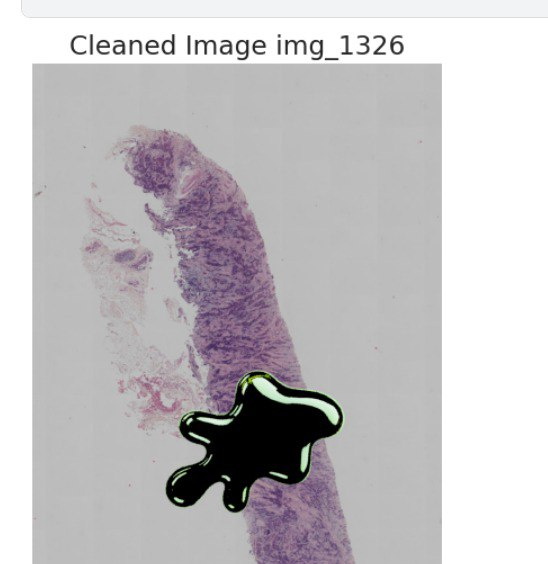

In [93]:
#finds some contour and cuts away little central area of the blobs

import cv2
import numpy as np
import os
from tqdm import tqdm

def clean_goo_by_contour(df, cleaned_dir="train_data_cleaned", cleaned_mask_dir="train_masks_cleaned"):
    """
    Removes green goo using contour detection. Everything inside detected green blobs
    will be set to black in the image and 0 in the mask.
    """
    os.makedirs(cleaned_dir, exist_ok=True)
    os.makedirs(cleaned_mask_dir, exist_ok=True)

    cleaned_img_paths = []
    cleaned_mask_paths = []

    for img_path, mask_path in tqdm(zip(df['image_path'], df['mask_path']), total=len(df), desc="Cleaning goo by contour"):
        # Load image and mask
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Convert to HSV and threshold green
        hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        lower_green = np.array([50, 80, 80])   # adjust if needed
        upper_green = np.array([90, 255, 255])
        green_mask = cv2.inRange(hsv, lower_green, upper_green)

        # Optional: close small holes in green mask
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
        green_mask = cv2.morphologyEx(green_mask, cv2.MORPH_CLOSE, kernel)

        # Find contours of green regions
        contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Fill the contours in image and mask
        cv2.drawContours(img_rgb, contours, -1, (0,0,0), thickness=cv2.FILLED)
        cv2.drawContours(mask, contours, -1, 0, thickness=cv2.FILLED)

        # Save cleaned image and mask
        base_name = os.path.basename(img_path)
        cleaned_img_path = os.path.join(cleaned_dir, base_name)
        cleaned_mask_path = os.path.join(cleaned_mask_dir, base_name)

        cv2.imwrite(cleaned_img_path, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
        cv2.imwrite(cleaned_mask_path, mask)

        cleaned_img_paths.append(cleaned_img_path)
        cleaned_mask_paths.append(cleaned_mask_path)

    # Update DataFrame
    df_cleaned = df.copy()
    df_cleaned['image_path'] = cleaned_img_paths
    df_cleaned['mask_path'] = cleaned_mask_paths

    return df_cleaned
    


the code above produces.

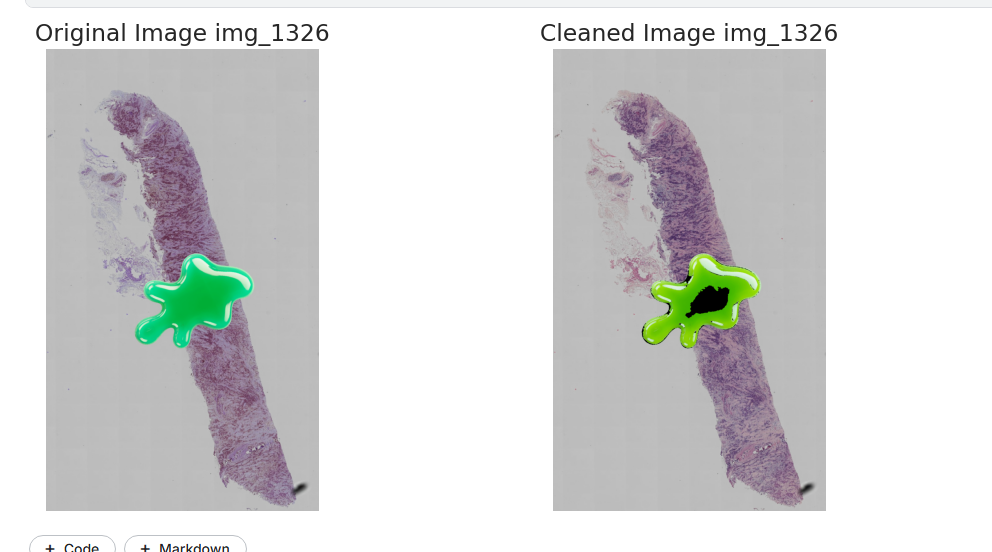

In [96]:
import cv2
import numpy as np
import os
from tqdm import tqdm
import pandas as pd

# The optimized HSV bounds based on the Shrek color palette (H=26 to H=90)
# These values are set to specifically target the yellow-browns and greens
# while avoiding the pink/red H&E stain.
LOWER_GREEN_HSV = np.array([26, 5, 5]) 
UPPER_GREEN_HSV = np.array([90, 255, 255])

def clean_goo_by_contour_inpainting(df, cleaned_dir="./train_data_cleaned", cleaned_mask_dir="./train_masks_cleaned"):
    """
    Removes green/yellow goo by identifying its outer contour and marking 
    the entire enclosed area for inpainting, thus removing the whole blob 
    including internal shades and highlights.

    Args:
        df (pd.DataFrame): DataFrame containing 'image_path' and 'mask_path'.
        cleaned_dir (str): Directory to save cleaned images.
        cleaned_mask_dir (str): Directory to save updated masks.
    """
    os.makedirs(cleaned_dir, exist_ok=True)
    os.makedirs(cleaned_mask_dir, exist_ok=True)

    cleaned_img_paths = []
    cleaned_mask_paths = []

    for img_path, mask_path in tqdm(zip(df['image_path'], df['mask_path']), total=len(df), desc="Precise green goo cleaning and inpainting"):
        # We read the image and mask
        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None or mask is None:
            print(f"Skipping missing image or mask: {os.path.basename(img_path)}")
            continue

        # Convert to HSV (using BGR since OpenCV reads files in BGR by default)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # 1. Green mask threshold (using optimized palette bounds)
        # This initial mask is only used to find the contours (outer boundaries) of the goo.
        green_mask = cv2.inRange(hsv, LOWER_GREEN_HSV, UPPER_GREEN_HSV)

        # 2. Morphological closing to smooth the goo boundary
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
        green_mask = cv2.morphologyEx(green_mask, cv2.MORPH_CLOSE, kernel)

        # 3. Find contours of the green blobs
        contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # The mask used for inpainting must be a single 8-bit mask (0 or 255)
        inpaint_mask = np.zeros_like(green_mask, dtype=np.uint8)

        # 4. Iterate contours to build the final removal mask
        for cnt in contours:
            # Create a contour mask that fills the entire area enclosed by the green blob's outline
            contour_area_mask = np.zeros_like(green_mask, dtype=np.uint8)
            
            # Draw the filled contour based on the detected green boundary.
            cv2.drawContours(contour_area_mask, [cnt], -1, 255, thickness=cv2.FILLED)

            # CRITICAL MODIFICATION: Mark the entire area inside the contour for removal.
            # This handles internal shades, highlights, or non-green parts of the contamination.
            inpaint_mask[contour_area_mask > 0] = 255

        # 5. Apply Inpainting (only if contamination exists)
        if np.count_nonzero(inpaint_mask) > 0:
            # Use INPAINT_TELEA to reconstruct the background/tissue texture
            # This step fills the hole using surrounding healthy tissue pixels.
            img = cv2.inpaint(img, inpaint_mask, 3, cv2.INPAINT_TELEA) 
        
        # 6. Update tissue mask (mask)
        # We set the area where goo was removed to 0 (background) in the tissue mask.
        mask[inpaint_mask > 0] = 0

        # 7. Save cleaned image and mask
        base_name = os.path.basename(img_path)
        cleaned_img_path = os.path.join(cleaned_dir, base_name)
        # Ensure we correctly name the mask file based on convention
        cleaned_mask_path = os.path.join(cleaned_mask_dir, base_name.replace("img_", "mask_"))
        
        cv2.imwrite(cleaned_img_path, img) # img is still BGR
        cv2.imwrite(cleaned_mask_path, mask)

        cleaned_img_paths.append(cleaned_img_path)
        cleaned_mask_paths.append(cleaned_mask_path)

    df_cleaned = df.copy()
    df_cleaned['image_path'] = cleaned_img_paths
    df_cleaned['mask_path'] = cleaned_mask_paths

    return df_cleaned

the code above produces:

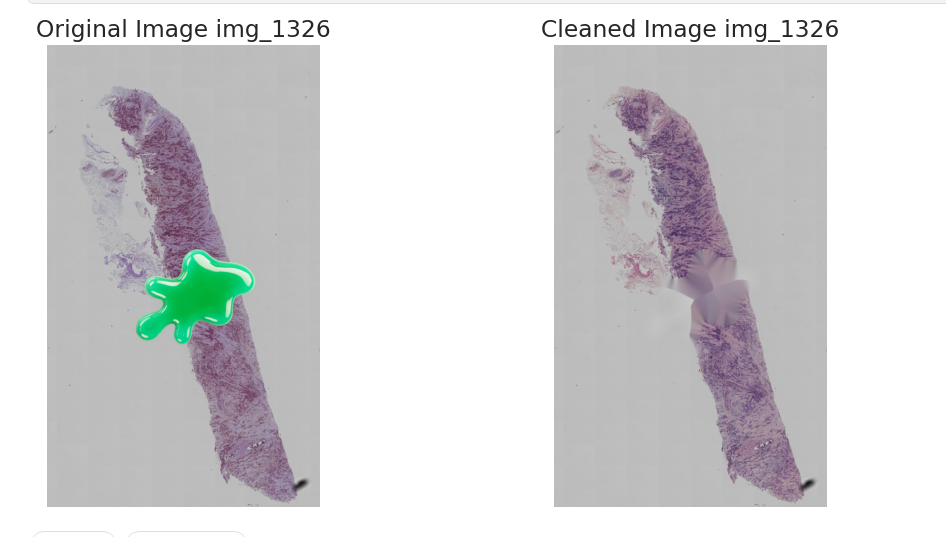
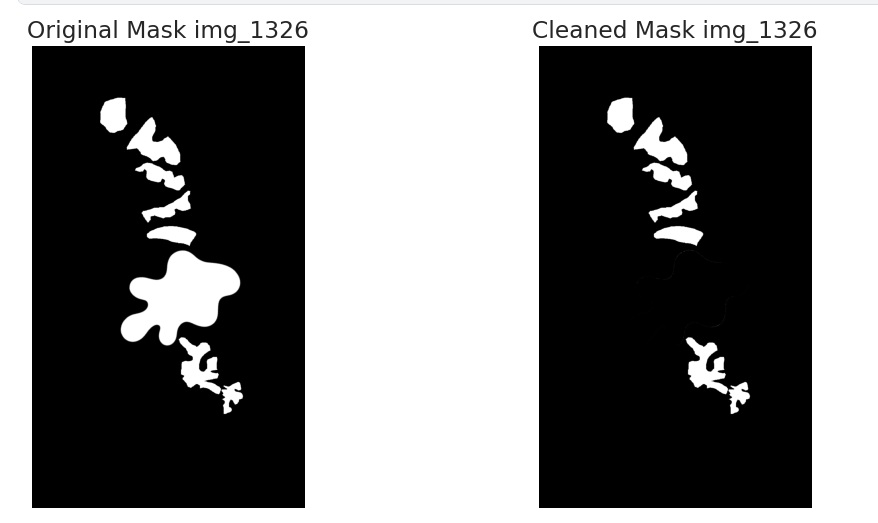

# MAIN

In [97]:
df_full = get_clean_dataframe(data_root="../input/datasetch2/")
df_no_shrek = remove_shrek(df_full)

#save_noshrek_dataset(df_noshrek, output_root="train_noshrek")

#worked well for green pixels, but the goo is not uniform. we need to remove contour wise
# df_cleaned = clean_green_goo_with_mask(
#     df_no_shrek,
#     cleaned_dir="../working/train_data_cleaned/",
#     cleaned_mask_dir="../working/train_masks_cleaned/"
# )
df_cleaned_contour = clean_goo_by_contour_inpainting(
    df_no_shrek,
    cleaned_dir="../working/train_data_cleaned_contour/",
    cleaned_mask_dir="../working/train_masks_cleaned_contour/"
)


Successfully merged 1412 images with their labels.

--- Manual Shrek Removal ---
Rows before: 1412
Rows after:  1278
Shrek removed: 134
----------------------------



Precise green goo cleaning and inpainting: 100%|██████████| 1278/1278 [08:48<00:00,  2.42it/s]


In [57]:
print("Shape:", df_no_shrek.shape)
print("\nColumns:", df_no_shrek.columns.tolist())

print("\nDataFrame Info:")
print(df_no_shrek.info())

print("\nFirst 10 rows:")
print(df_no_shrek.head(10))


Shape: (1278, 4)

Columns: ['sample_index', 'image_path', 'mask_path', 'label']

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1278 entries, 662 to 978
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sample_index  1278 non-null   int64 
 1   image_path    1278 non-null   object
 2   mask_path     1278 non-null   object
 3   label         1278 non-null   object
dtypes: int64(1), object(3)
memory usage: 49.9+ KB
None

First 10 rows:
      sample_index                                   image_path  \
662              0  ../input/datasetch2/train_data/img_0000.png   
1164             1  ../input/datasetch2/train_data/img_0001.png   
1355             2  ../input/datasetch2/train_data/img_0002.png   
64               3  ../input/datasetch2/train_data/img_0003.png   
933              4  ../input/datasetch2/train_data/img_0004.png   
269              5  ../input/datasetch2/train_data/img_0005.png   
1396    

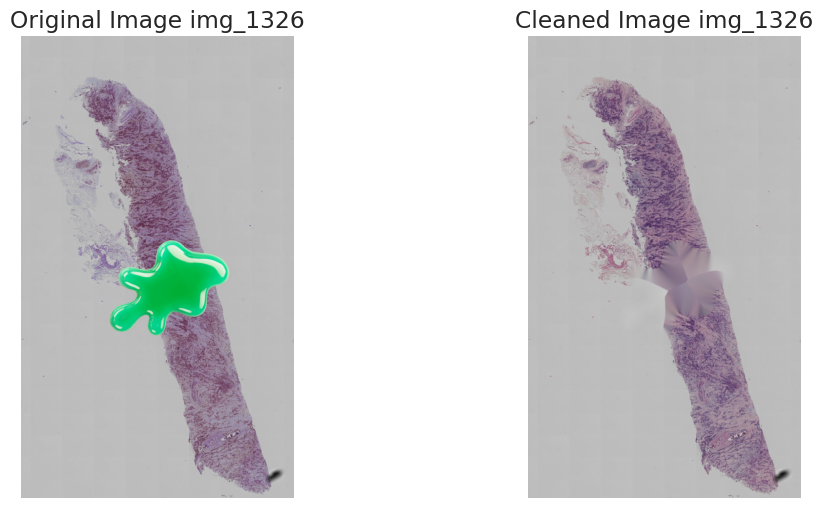

In [98]:
# --- Get original mask from df_no_shrek ---
row_original = df_no_shrek[df_no_shrek['sample_index'] == 1326].iloc[0]
original_img_path = row_original['image_path']
original_img = cv2.imread(original_img_path, cv2.COLOR_BGR2RGB)


# Example to visualize cleaned image
row = df_cleaned_contour[df_cleaned['sample_index'] == 1326].iloc[0]
img = cv2.imread(row['image_path'])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(original_img)
plt.title("Original Image img_1326")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Cleaned Image img_1326")
plt.show()


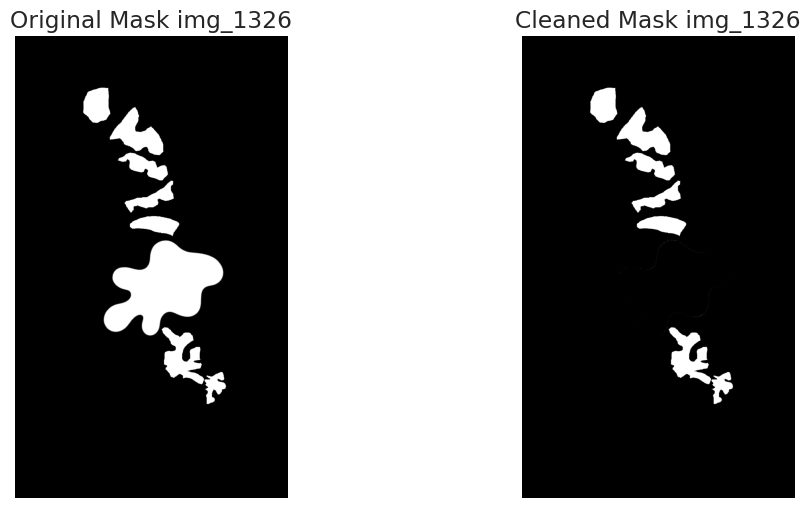

In [99]:
import cv2
import matplotlib.pyplot as plt

# --- Get original mask from df_no_shrek ---
row_original = df_no_shrek[df_no_shrek['sample_index'] == 1326].iloc[0]
original_mask_path = row_original['mask_path']
original_mask = cv2.imread(original_mask_path, cv2.IMREAD_GRAYSCALE)

# --- Get cleaned mask from df_cleaned ---
row_cleaned = df_cleaned_contour[df_cleaned['sample_index'] == 1326].iloc[0]
cleaned_mask_path = row_cleaned['mask_path']
cleaned_mask = cv2.imread(cleaned_mask_path, cv2.IMREAD_GRAYSCALE)

# --- Plot side by side ---
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(original_mask, cmap='gray')
plt.title("Original Mask img_1326")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cleaned_mask, cmap='gray')
plt.title("Cleaned Mask img_1326")
plt.axis('off')

plt.show()


In [110]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# --- CONFIGURATION: Define the exact indices you want to inspect ---
# We will assume you meant the unique indices: 102, 108, 152, 153 (4 images total)
IMAGES_TO_VIEW = [102, 108, 152, 153]
# -----------------------------------------------------------------

# --- MOCK DATA SETUP ---
# NOTE: This section is kept to allow the script to run even if 'df_cleaned_contour' is not defined.
try:
    # Use the actual DataFrame passed from the contour cleaning function
    all_image_paths = df_cleaned_contour['image_path'].tolist()
    all_mask_paths = df_cleaned_contour['mask_path'].tolist()
    n_total_images = len(all_image_paths)
except NameError:
    print("Warning: 'df_cleaned_contour' not found. Using mock data paths for visualization test.")
    # Fallback to creating a mock DataFrame with enough paths to cover requested indices.
    MOCK_DIR = "./mock_data"
    os.makedirs(MOCK_DIR, exist_ok=True)
    
    # Ensure mock count covers the highest requested index + 1
    MOCK_COUNT = max(IMAGES_TO_VIEW) + 1 
    all_image_paths = [f"{MOCK_DIR}/img_{i}.png" for i in range(MOCK_COUNT)]
    all_mask_paths = [f"{MOCK_DIR}/mask_{i}.png" for i in range(MOCK_COUNT)]
    n_total_images = MOCK_COUNT
    
    # Create simple mock images if they don't exist (for full runnability)
    for p in all_image_paths + all_mask_paths:
        if not os.path.exists(p):
            mock_img = np.zeros((100, 100, 3), dtype=np.uint8)
            cv2.imwrite(p, mock_img)
# --- END MOCK DATA SETUP ---


n_images_to_show = len(IMAGES_TO_VIEW)
n_rows = int(np.ceil(n_images_to_show / 2.0)) # Max 2 pairs per row
n_cols = 4 # Fixed layout: Image | Mask || Image | Mask (4 columns)

print(f"Total images available in dataset: {n_total_images}")
print(f"Displaying {n_images_to_show} selected images: {IMAGES_TO_VIEW}")

# Figure and axes: dynamic rows (1 or 2), 4 columns
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
plt.subplots_adjust(wspace=0.1, hspace=0.3)
fig.suptitle(f"Cleaned Image and Mask Visualization (Selected Indices: {IMAGES_TO_VIEW})", fontsize=16)

# Flatten the axes array for easier indexing, handle case where n_rows=1
if n_rows == 1:
    axes = np.array([axes]).flatten()
else:
    axes = axes.flatten()

# This tracks the index within the IMAGES_TO_VIEW array (0 to 3)
for plot_idx, global_img_idx in enumerate(IMAGES_TO_VIEW):
    
    if global_img_idx >= n_total_images:
        print(f"Skipping index {global_img_idx}: Index out of bounds (max index is {n_total_images - 1}).")
        continue

    # Determine the visual row (0 or 1)
    row = plot_idx // 2 
    # Determine if it's the left pair (0) or right pair (1)
    pair_index_in_row = plot_idx % 2 

    # Calculate image column (0 or 2) and mask column (1 or 3)
    col_img = pair_index_in_row * 2
    col_mask = pair_index_in_row * 2 + 1

    # Calculate index in the flattened axes array:
    ax_img_idx = row * n_cols + col_img
    ax_mask_idx = row * n_cols + col_mask
    
    # Get the specific axes objects
    ax_img = axes[ax_img_idx]
    ax_mask = axes[ax_mask_idx]

    try:
        # Load image and mask
        # Note: We must access the original list of paths using the global_img_idx
        img = cv2.cvtColor(cv2.imread(all_image_paths[global_img_idx]), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(all_mask_paths[global_img_idx], cv2.IMREAD_GRAYSCALE)

        # Plot Image
        ax_img.imshow(img)
        ax_img.set_title(f"Image {global_img_idx}", fontsize=10)
        ax_img.axis('off')
        ax_img.set_aspect('equal')

        # Plot Mask
        ax_mask.imshow(mask, cmap='gray')
        ax_mask.set_title(f"Mask {global_img_idx}", fontsize=10)
        ax_mask.axis('off')
        ax_mask.set_aspect('equal')
        
    except Exception as e:
        ax_img.set_title(f"Error loading {global_img_idx}", fontsize=10)
        ax_mask.set_title(f"Error loading {global_img_idx}", fontsize=10)
        print(f"Could not load image {global_img_idx} at {all_image_paths[global_img_idx]}: {e}")
        
# Clear any unused axes slots
plots_used = n_images_to_show * 2
for j in range(plots_used, len(axes)):
    axes[j].remove()

plt.show()

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (1981794736.py, line 9)

Total available images: 1278
Displaying the first 300 images.


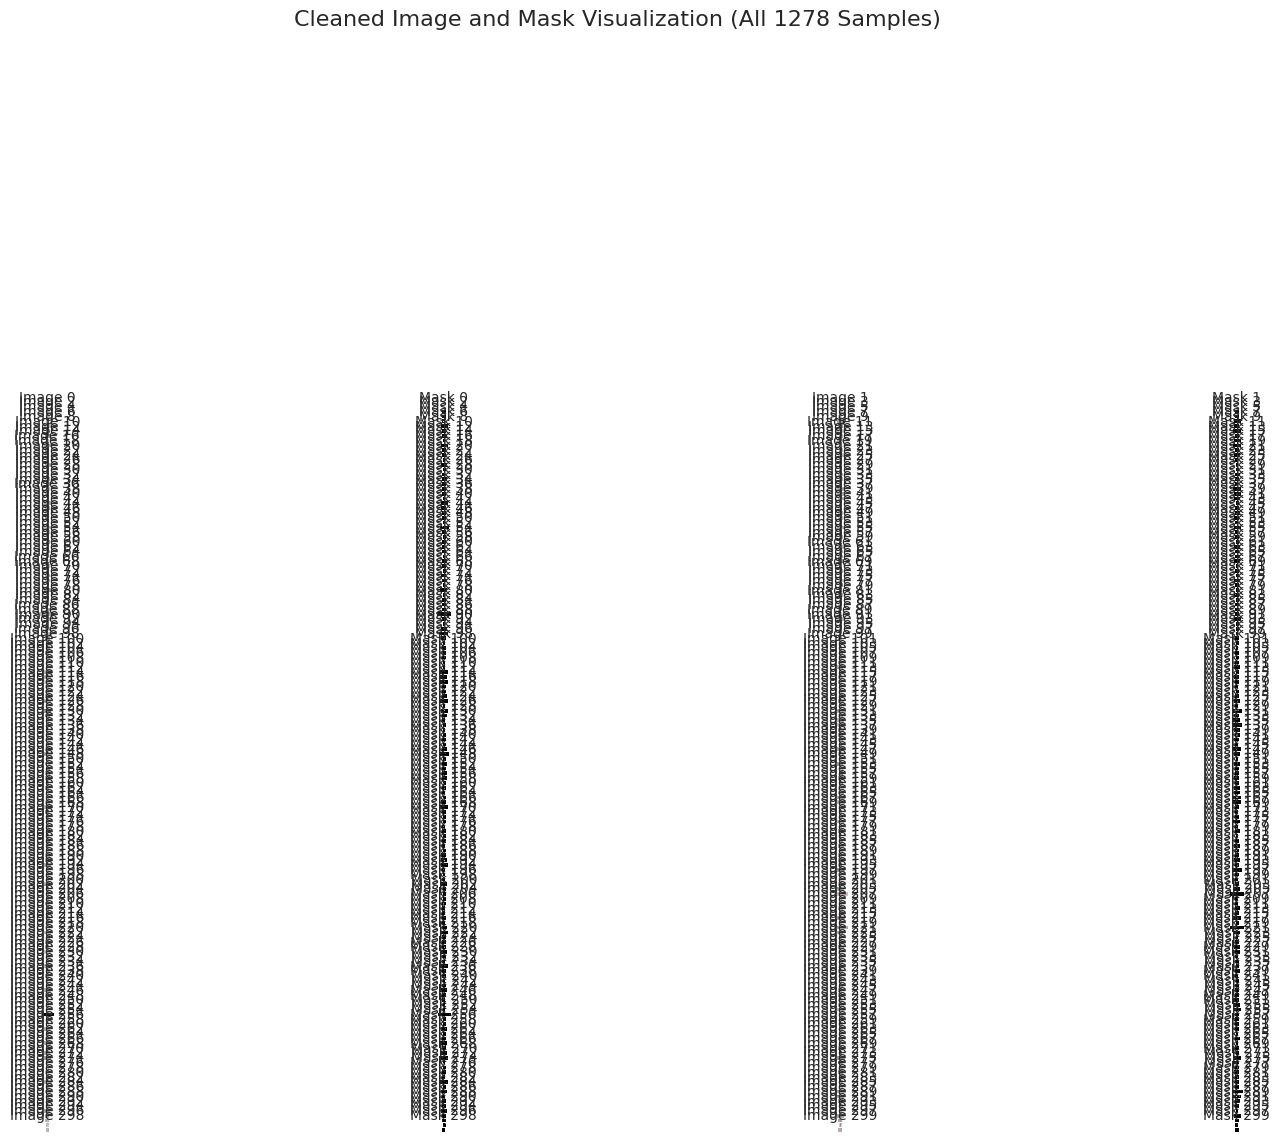

In [108]:
#works really badly 

# import cv2
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# import os

# try:
#     # Use the actual DataFrame passed from the contour cleaning function
#     image_paths = df_cleaned_contour['image_path'].tolist()
#     mask_paths = df_cleaned_contour['mask_path'].tolist()
# except NameError:
#     print("Warning: 'df_cleaned_contour' not found. Using mock data paths for visualization test.")
#     # Fallback to creating a mock DataFrame for demonstration purposes
#     # In a real scenario, these mock paths would need to point to existing files.
#     MOCK_DIR = "./mock_data"
#     os.makedirs(MOCK_DIR, exist_ok=True)
    
#     # Create mock paths (assuming image files img_0.png... exist)
#     mock_paths = [f"{MOCK_DIR}/img_{i}.png" for i in range(12)]
#     mock_mask_paths = [f"{MOCK_DIR}/mask_{i}.png" for i in range(12)]
    
#     # Create simple mock images if they don't exist (for full runnability)
#     # If you run this file, you will see blank mock images.
#     for p in mock_paths + mock_mask_paths:
#         if not os.path.exists(p):
#             mock_img = np.zeros((100, 100, 3), dtype=np.uint8)
#             cv2.imwrite(p, mock_img)

#     image_paths = mock_paths
#     mask_paths = mock_mask_paths


# n_images = len(image_paths)
# images_to_display = 300

# n_cols = 4 # Two columns for image/mask pairs, side-by-side (Image, Mask | Image, Mask)
# n_rows = int(np.ceil(n_images / 2.0))

# FIGURE_HEIGHT = n_rows *3.0
# # Cap height to prevent rendering issues with massive datasets
# MAX_HEIGHT = 40
# FIGURE_HEIGHT = min(FIGURE_HEIGHT, MAX_HEIGHT) 

# print(f"Total available images: {n_images}")
# print(f"Displaying the first {min(n_images, images_to_display)} images.")

# # Figure and axes: dynamic rows, 4 columns
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, FIGURE_HEIGHT))
# plt.subplots_adjust(wspace=0.1, hspace=0.3)
# fig.suptitle(f"Cleaned Image and Mask Visualization (All {n_images} Samples)", fontsize=16)


# # Flatten the axes array for easier indexing, handle case where n_rows=1
# if n_rows == 1:
#     # Handle the case where there is only 1 row (i.e., 1 or 2 images total)
#     axes = np.array([axes]).flatten()
# elif n_rows > 1:
#     axes = axes.flatten()

# # This is the last index in the image_paths array
# last_image_index = -1 


# for i in range(images_to_display):
#     last_image_index = i # Keep track of the last index successfully accessed
    
#     # Determine the visual row (0, 1, 2, ...)
#     row = i // 2 
#     # Determine if it's the left pair (0) or right pair (1)
#     pair_index_in_row = i % 2 

#     # Calculate image column (0 or 2) and mask column (1 or 3)
#     col_img = pair_index_in_row * 2
#     col_mask = pair_index_in_row * 2 + 1

#     # Calculate index in the flattened axes array:
#     ax_img_idx = row * n_cols + col_img
#     ax_mask_idx = row * n_cols + col_mask
    
#     # Get the specific axes objects
#     ax_img = axes[ax_img_idx]
#     ax_mask = axes[ax_mask_idx]

#     try:
#         # Load image and mask
#         # cv2.imread loads BGR, convert to RGB for matplotlib
#         img = cv2.cvtColor(cv2.imread(image_paths[i]), cv2.COLOR_BGR2RGB)
#         mask = cv2.imread(mask_paths[i], cv2.IMREAD_GRAYSCALE)

#         # Plot Image
#         ax_img.imshow(img)
#         ax_img.set_title(f"Image {i}", fontsize=10)
#         ax_img.axis('off')
#         # Fix: Set aspect ratio to equal to prevent vertical squishing
#         ax_img.set_aspect('equal')

#         # Plot Mask
#         ax_mask.imshow(mask, cmap='gray')
#         ax_mask.set_title(f"Mask {i}", fontsize=10)
#         ax_mask.axis('off')
#         # Fix: Set aspect ratio to equal to prevent vertical squishing
#         ax_mask.set_aspect('equal')
        
#     except Exception as e:
#         ax_img.set_title(f"Error loading {i}", fontsize=10)
#         ax_mask.set_title(f"Error loading {i}", fontsize=10)
#         print(f"Could not load image {i} at {image_paths[i]}: {e}")
        
# # Clear any unused axes slots at the end (e.g., if total images is odd)
# # We start clearing from the first unused slot: (last_image_index + 1) * 2
# plots_used = (last_image_index + 1) * 2
# # Ensure we don't try to clear if last_image_index was -1 (no images)
# if plots_used > 0:
#     for j in range(plots_used, len(axes)):
#         axes[j].remove()

# plt.show()